In [114]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [115]:
df = pd.read_csv("StudentPerformanceFactors.csv")

In [116]:
df.shape

(6607, 20)

In [117]:
df.head(20)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


In [118]:
num_cols = df.select_dtypes(include='number').columns

print("There are", len(num_cols) ," number of columns")
print("The Numerical Columns are: ", list(num_cols))


There are 7  number of columns
The Numerical Columns are:  ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']


In [119]:
calculation = pd.DataFrame({
    "Mean": df[num_cols].mean(),
    "Median": df[num_cols].median(),
    "Mode": df[num_cols].mode().iloc[0],
    "Variance": df[num_cols].var(),
    "Std Dev": df[num_cols].std(),
    "IQR": df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)
})

calculation

,Mean,Median,Mode,Variance,Std Dev,IQR
Hours_Studied,19.975329,20.0,20,35.887221,5.990594,8.0
Attendance,79.977448,80.0,67,133.344178,11.547475,20.0
Sleep_Hours,7.029060,7.0,7,2.155377,1.468120,2.0
Previous_Scores,75.070531,75.0,66,207.353789,14.399784,25.0
Tutoring_Sessions,1.493719,1.0,1,1.514304,1.230570,1.0
Physical_Activity,2.967610,3.0,3,1.063438,1.031231,2.0
Exam_Score,67.235659,67.0,68,15.135646,3.890456,4.0


<Figure size 640x480 with 0 Axes>

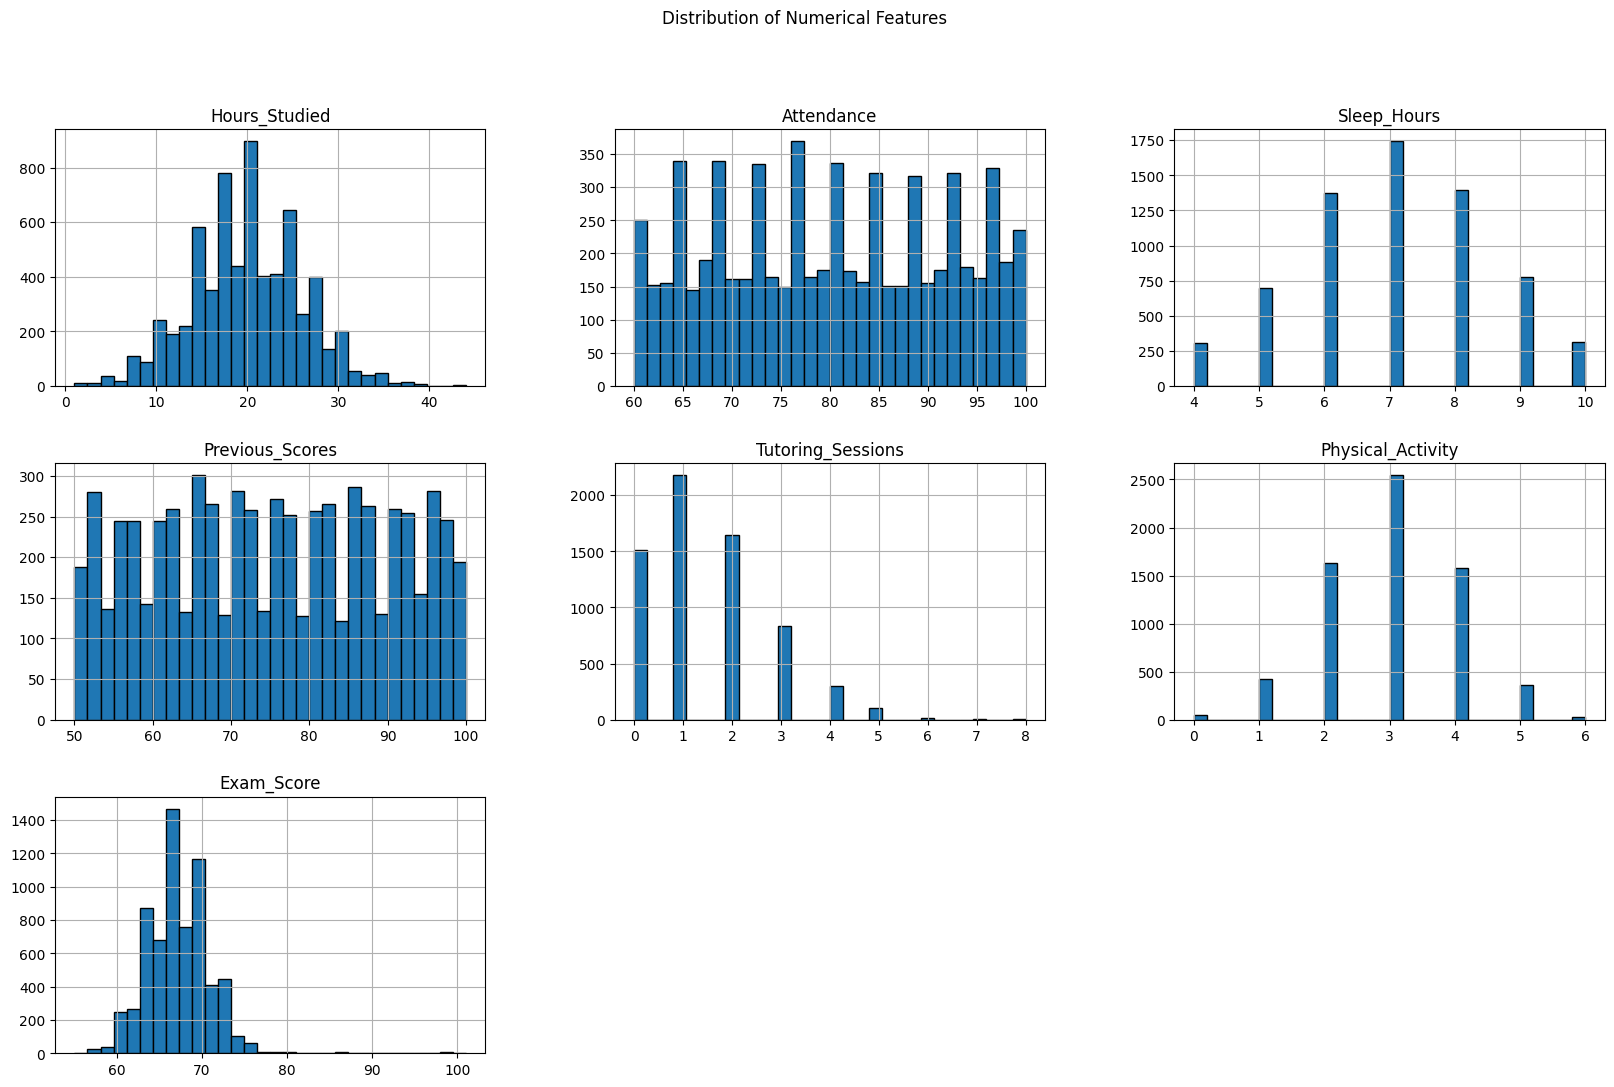

In [120]:
plt.figure()

df[num_cols].hist(bins =30,edgecolor = 'black',figsize=(20,12))
plt.suptitle("Distribution of Numerical Features")
plt.show()



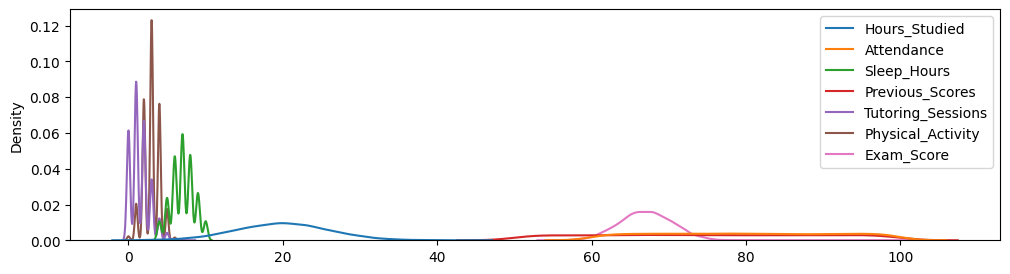

In [121]:
plt.figure(figsize = (12,3))
sns.kdeplot(df[num_cols])
plt.show()

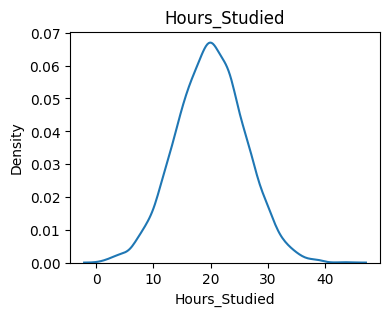

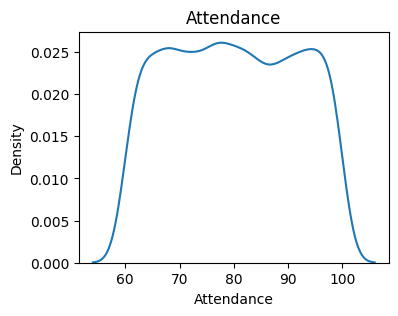

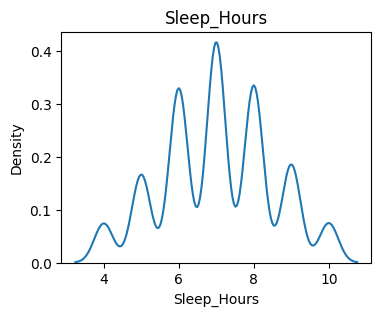

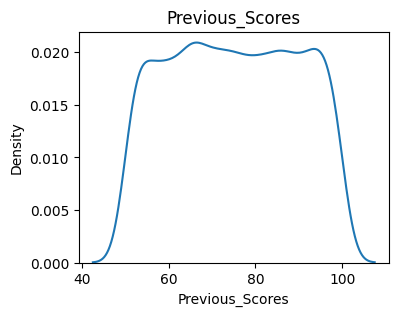

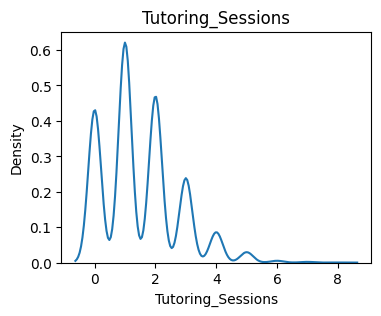

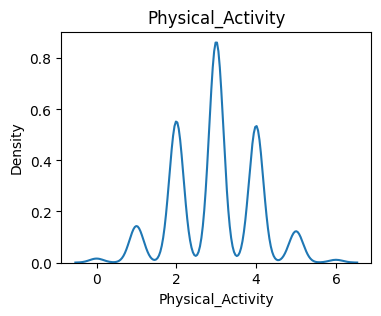

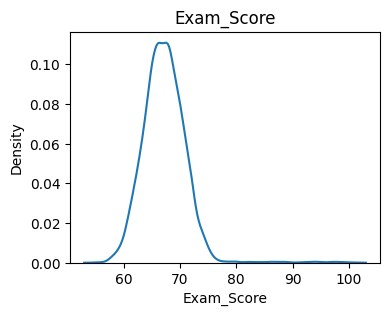

In [122]:
for col in num_cols:
    plt.figure(figsize=(4,3))
    sns.kdeplot(df[col])
    plt.title(col)
    plt.show()

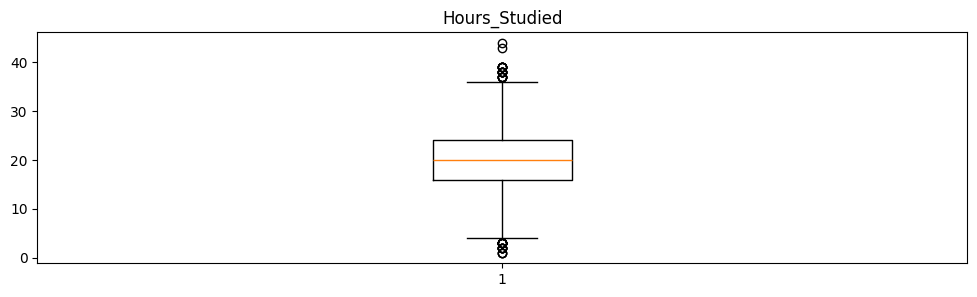

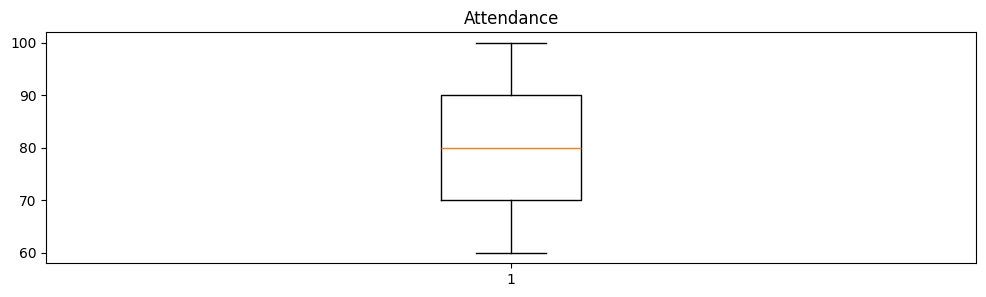

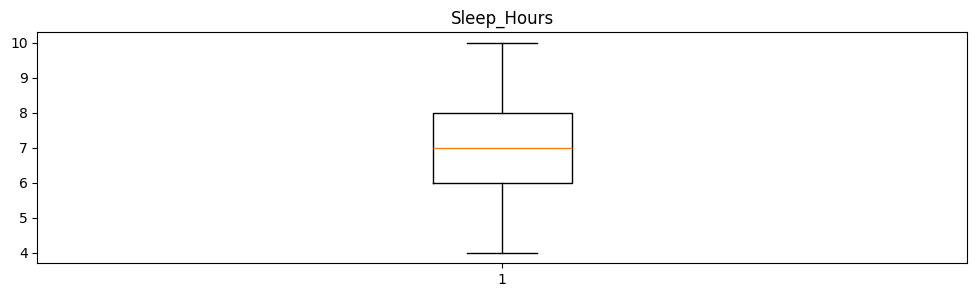

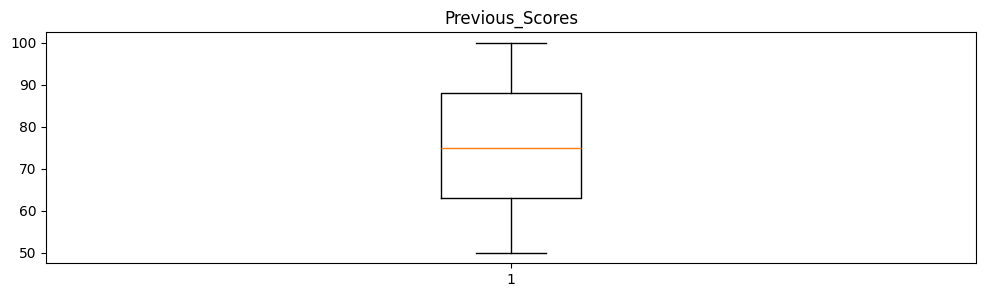

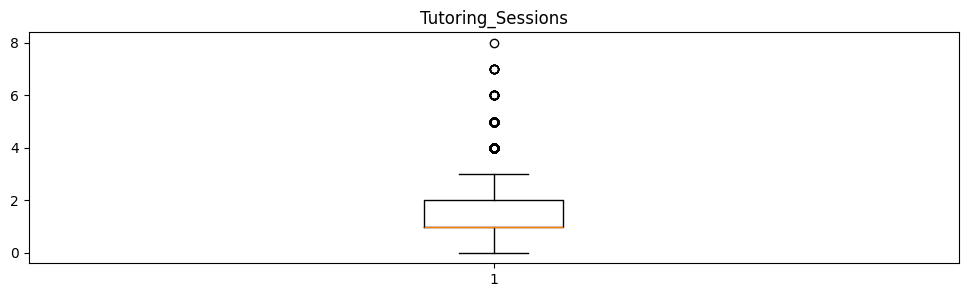

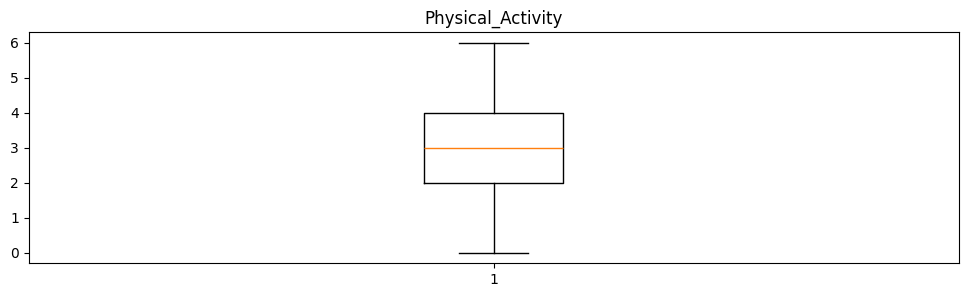

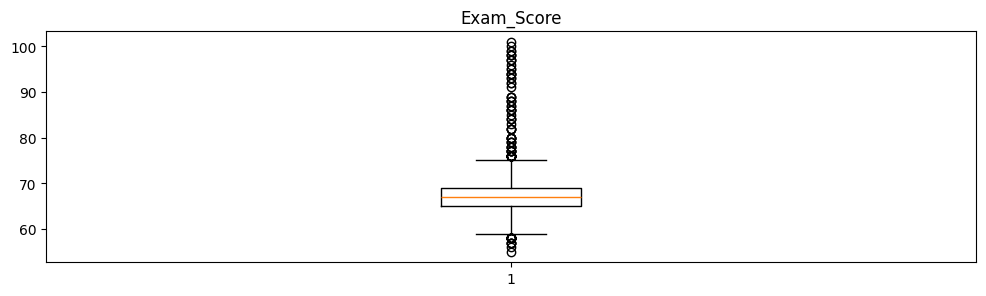

In [123]:
for col in num_cols:
    plt.figure(figsize=(12,3))
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

In [124]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3 - Q1

outliers = ((df[num_cols] < (Q1 - 1.5*IQR)) | (df[num_cols] > (Q3 + 1.5*IQR)))

outliers.sum()

Hours_Studied         43
Attendance             0
Sleep_Hours            0
Previous_Scores        0
Tutoring_Sessions    430
Physical_Activity      0
Exam_Score           104
dtype: int64

In [125]:
cat_cols = df.select_dtypes(include='string').columns

print("There are ", len(cat_cols)," categorical features")
print("The Categorical Columns are: ", list(cat_cols))

There are  13  categorical features
The Categorical Columns are:  ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


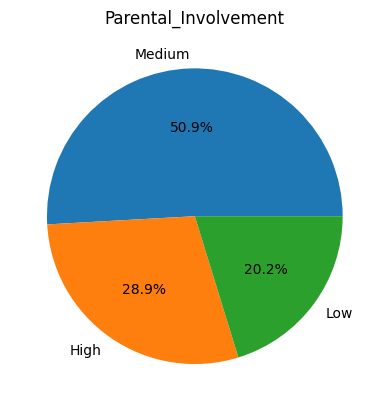

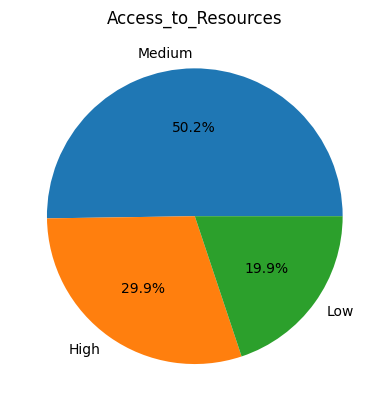

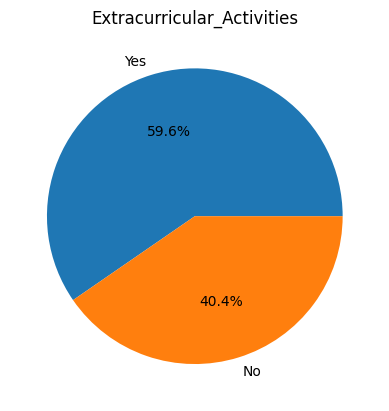

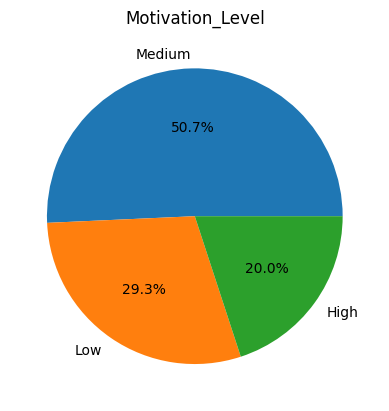

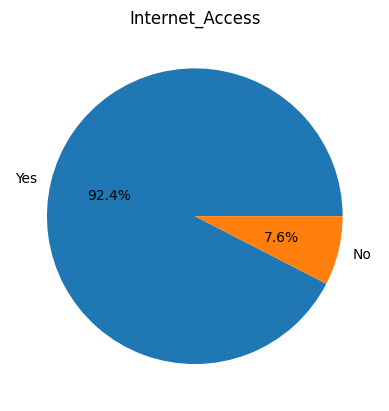

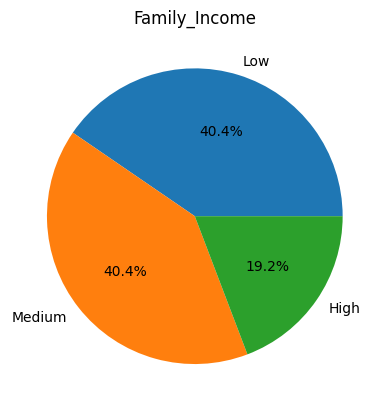

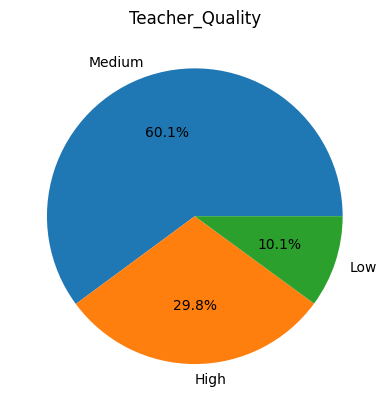

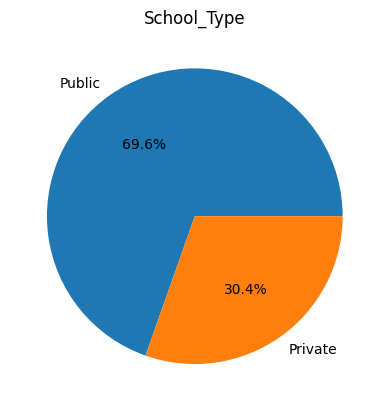

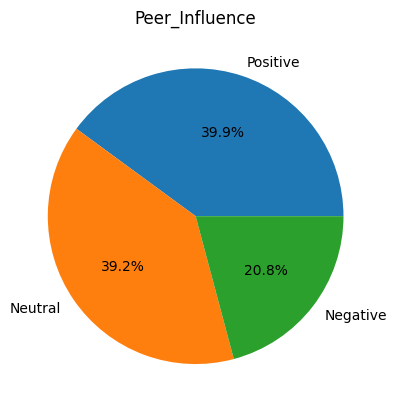

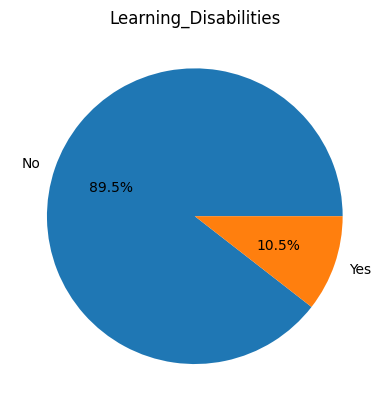

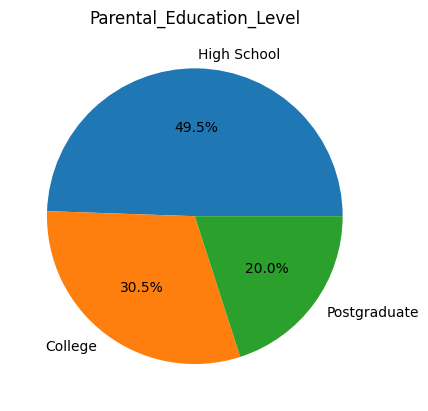

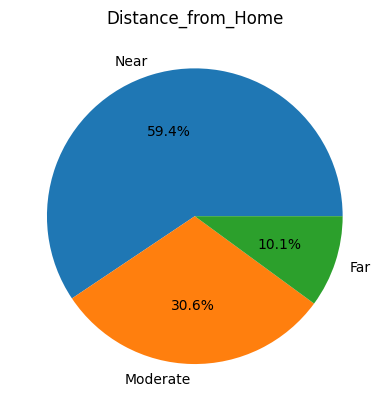

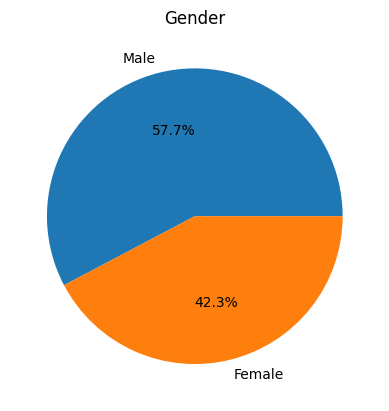

In [126]:
for col in cat_cols:
    df[col].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title(col)
    plt.ylabel("")
    plt.show()

In [127]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

C:\Users\tsnmi\AppData\Local\Temp\ipykernel_73368\1383039436.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='str')

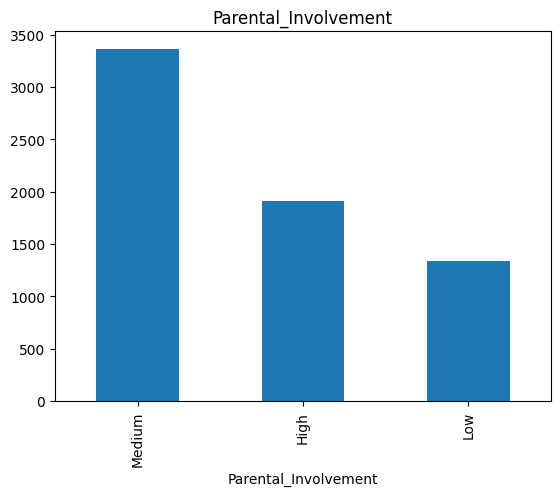

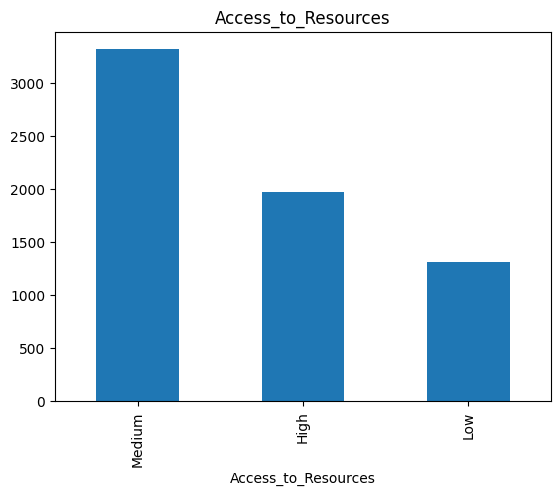

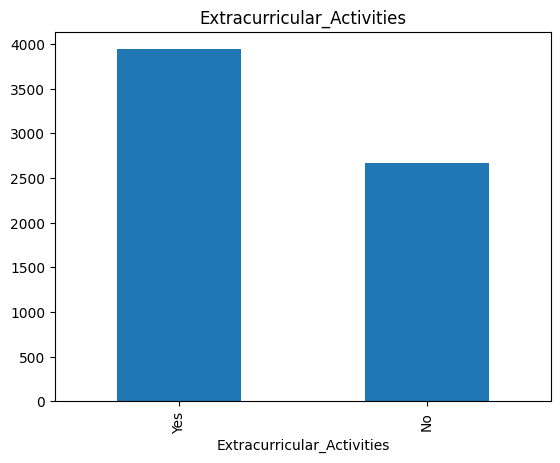

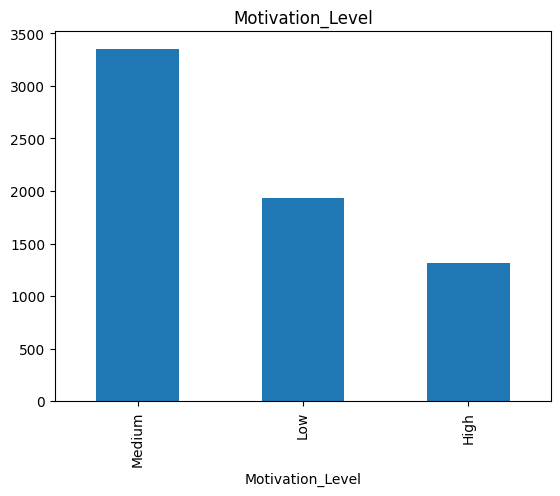

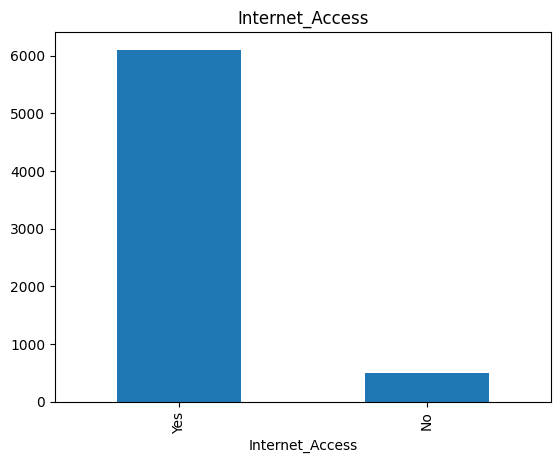

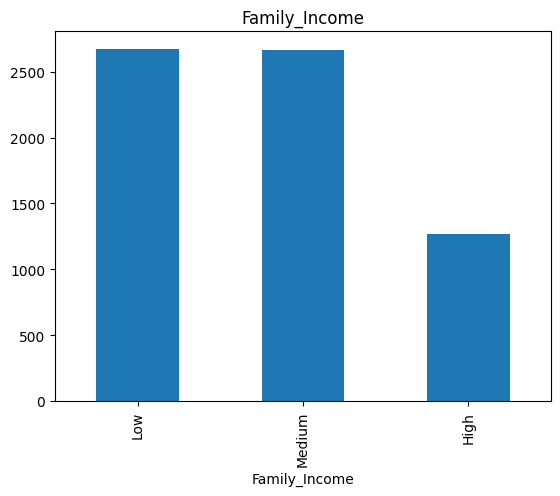

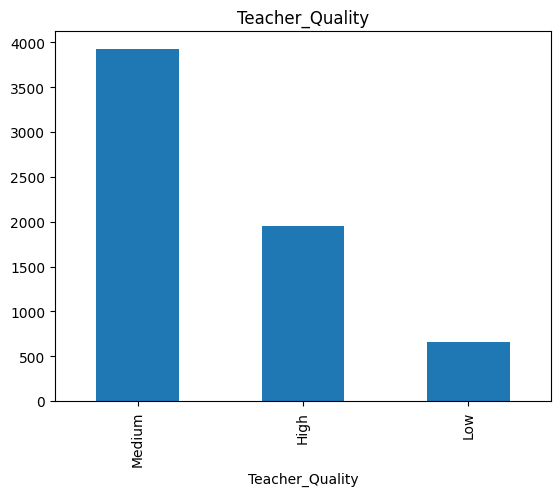

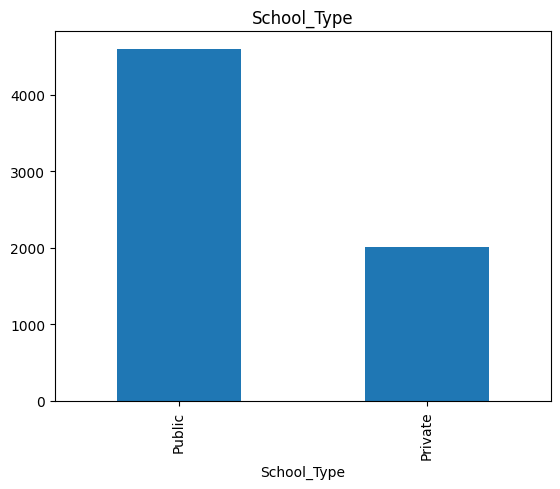

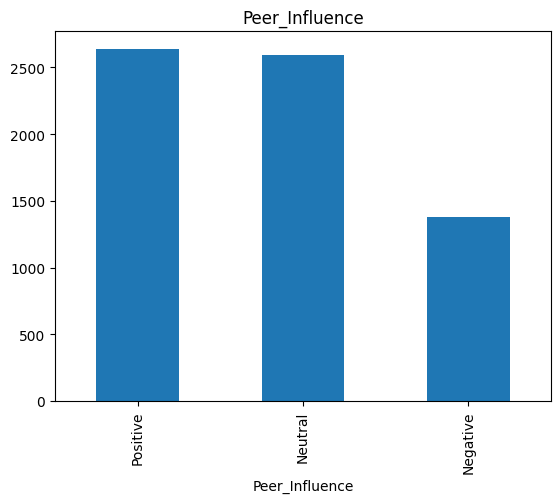

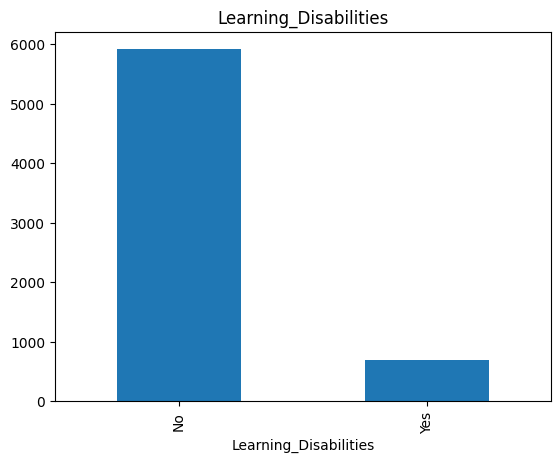

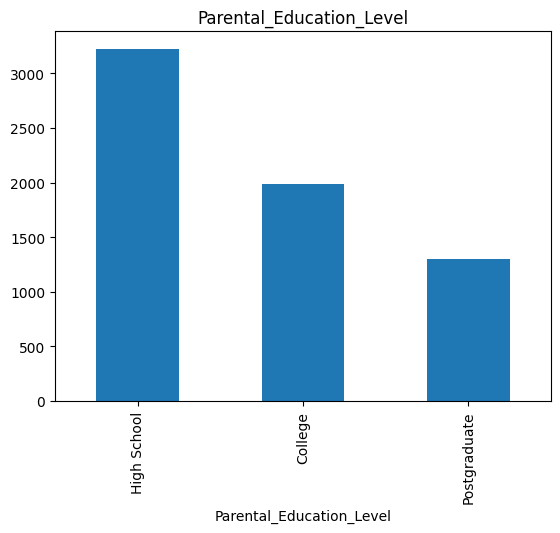

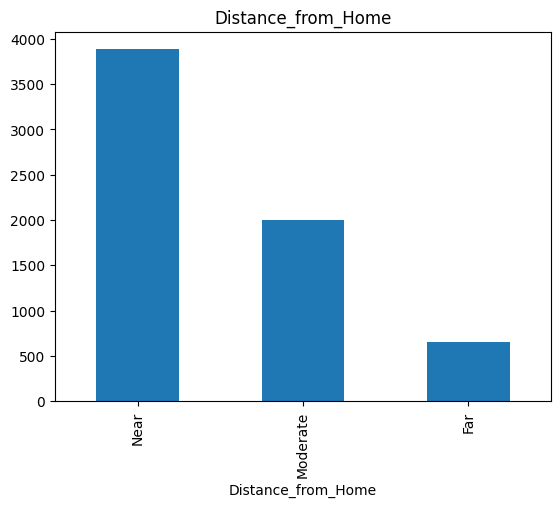

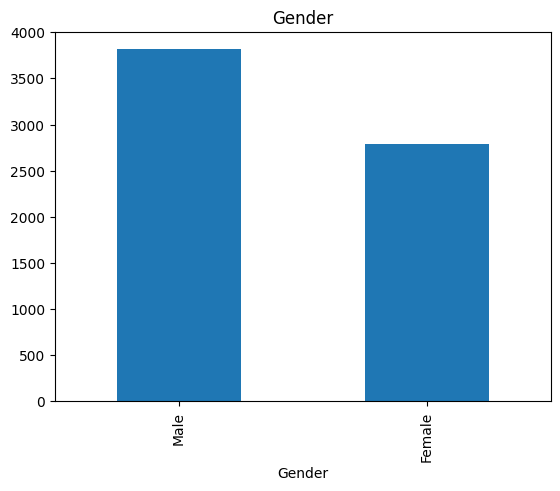

In [128]:
for col in cat_cols:
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

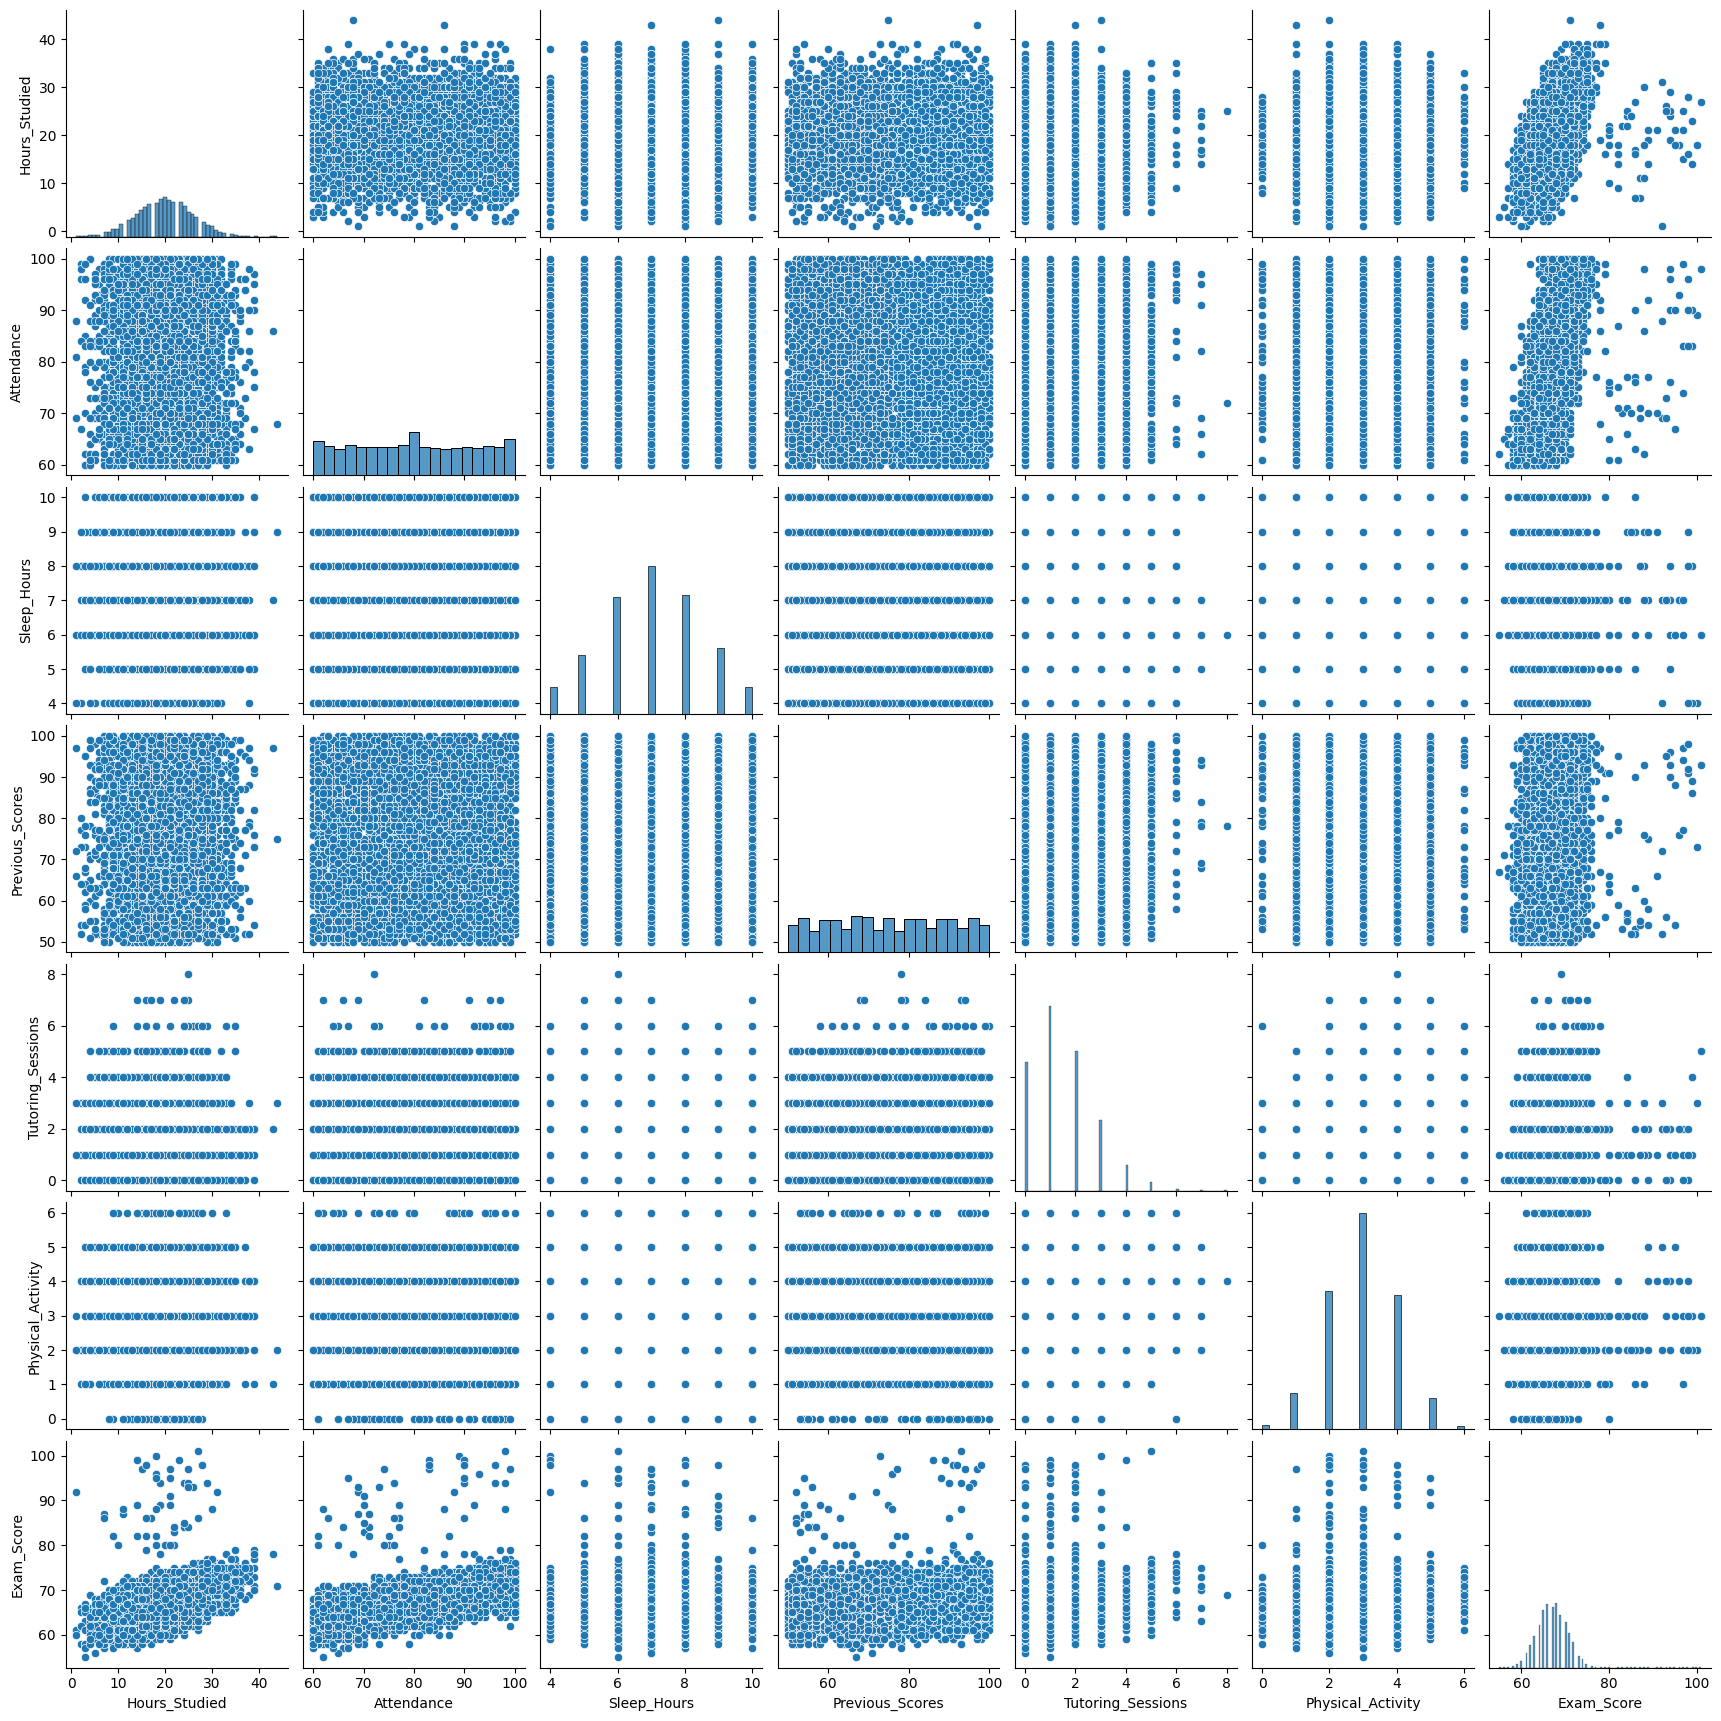

In [129]:
sns.pairplot(df[num_cols])
plt.show()

In [130]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [131]:
df.duplicated().sum()

np.int64(0)